In [27]:
!pip install torch torchvision timm scikit-learn opencv-python matplotlib

In [28]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [29]:
import os

print("Real:", len(os.listdir("/content/clean_dataset/real")))
print("Fake:", len(os.listdir("/content/clean_dataset/fake")))

Real: 262
Fake: 197


In [30]:
import os
import io
import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

# Check for GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda:0


In [31]:
# Hyperparameters
BATCH_SIZE = 16
EPOCHS = 25
LEARNING_RATE = 1e-4
IMG_SIZE = 256
DATA_DIR = "clean_dataset"
MODEL_SAVE_DIR = "models"

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Custom Transform to Simulate JPEG Compression
class JpegCompression(object):
    def __init__(self, quality_lower=60, quality_upper=90):
        self.quality_lower = quality_lower
        self.quality_upper = quality_upper

    def __call__(self, img):
        quality = np.random.randint(self.quality_lower, self.quality_upper)
        output = io.BytesIO()
        img.save(output, format="JPEG", quality=quality)
        output.seek(0)
        return Image.open(output)

# Data Augmentations
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ColorJitter(brightness=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomApply([JpegCompression(60, 90)], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


In [32]:
# ImageFolder assigns indices alphabetically (fake=0, real=1)
# We want to match requirement: real=0, fake=1
full_dataset = datasets.ImageFolder(DATA_DIR)
target_mapping = {
    full_dataset.class_to_idx['real']: 0,
    full_dataset.class_to_idx['fake']: 1
}
full_dataset.target_transform = lambda y: target_mapping[y]
full_dataset.classes = ['real', 'fake'] # Update classes list for labels

# Split dataset (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Dataset Wrapper to apply different transforms to train and val splits
class DatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

train_dataset = DatasetWrapper(train_dataset, transform=train_transforms)
val_dataset = DatasetWrapper(val_dataset, transform=val_transforms)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Total training images: {len(train_dataset)}")
print(f"Total validation images: {len(val_dataset)}")
print(f"Classes mapping: {full_dataset.classes} -> [0, 1]")


Total training images: 367
Total validation images: 92
Classes mapping: ['real', 'fake'] -> [0, 1]


In [33]:
# Load Pretrained MobileNetV3 Small
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

# Replace classifier for binary classification (1 output for BCEWithLogitsLoss)
num_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(num_features, 1)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [34]:
class EarlyStopping:
    def __init__(self, patience=3, delta=0, path='models/best_model.pth'):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)


In [35]:
# Training and Validation Tracking
train_losses, val_losses = [], []
early_stopping = EarlyStopping(patience=4, path=os.path.join(MODEL_SAVE_DIR, 'best_model.pth'))

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 15)

    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # --- Validation Phase ---
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = running_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)

    # Calculate Epoch Metrics
    acc = accuracy_score(all_labels, all_preds)

    print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {acc:.4f}")

    early_stopping(epoch_val_loss, model)
    scheduler.step(epoch_val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered. Halting training.")
        break



Epoch 1/25
---------------
Train Loss: 0.6377 | Val Loss: 0.5342 | Val Acc: 0.8261

Epoch 2/25
---------------
Train Loss: 0.4564 | Val Loss: 0.3876 | Val Acc: 0.8587

Epoch 3/25
---------------
Train Loss: 0.3302 | Val Loss: 0.2848 | Val Acc: 0.8913

Epoch 4/25
---------------
Train Loss: 0.2326 | Val Loss: 0.2201 | Val Acc: 0.9022

Epoch 5/25
---------------
Train Loss: 0.1810 | Val Loss: 0.1865 | Val Acc: 0.9239

Epoch 6/25
---------------
Train Loss: 0.1226 | Val Loss: 0.1667 | Val Acc: 0.9457

Epoch 7/25
---------------
Train Loss: 0.1086 | Val Loss: 0.1470 | Val Acc: 0.9348

Epoch 8/25
---------------
Train Loss: 0.0970 | Val Loss: 0.1470 | Val Acc: 0.9348

Epoch 9/25
---------------
Train Loss: 0.0731 | Val Loss: 0.1489 | Val Acc: 0.9239
EarlyStopping counter: 1 out of 4

Epoch 10/25
---------------
Train Loss: 0.0543 | Val Loss: 0.1499 | Val Acc: 0.9457
EarlyStopping counter: 2 out of 4

Epoch 11/25
---------------
Train Loss: 0.0432 | Val Loss: 0.1583 | Val Acc: 0.9348
EarlyS

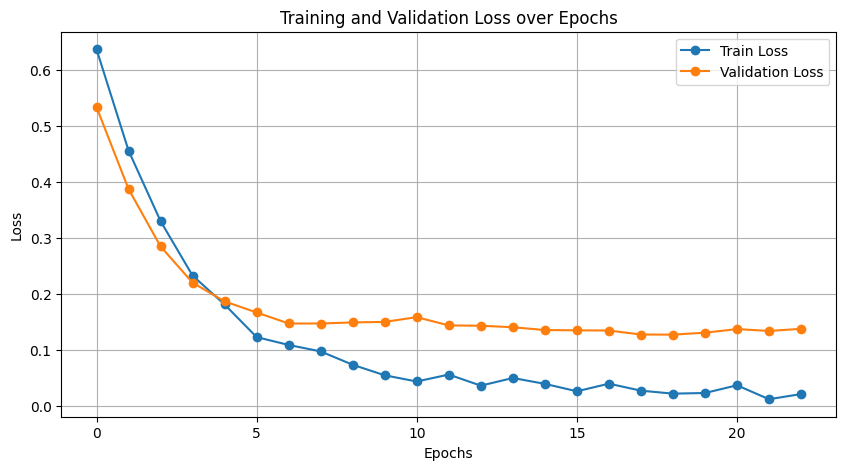

In [36]:
# Plot Training Curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


Evaluating best model on Validation Set...

--- Final Metrics ---
Accuracy  : 0.9348
Precision : 0.9048
Recall    : 0.9500
F1-Score  : 0.9268
ROC AUC   : 0.9889


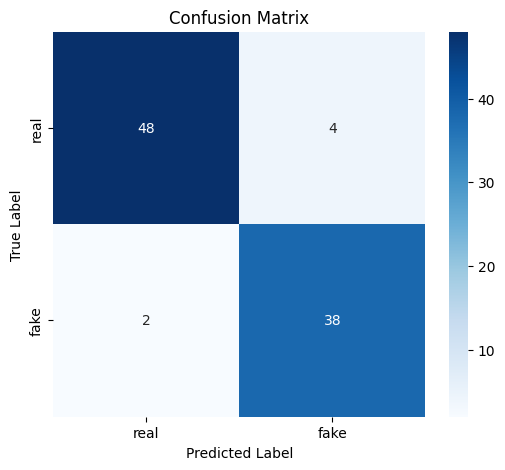

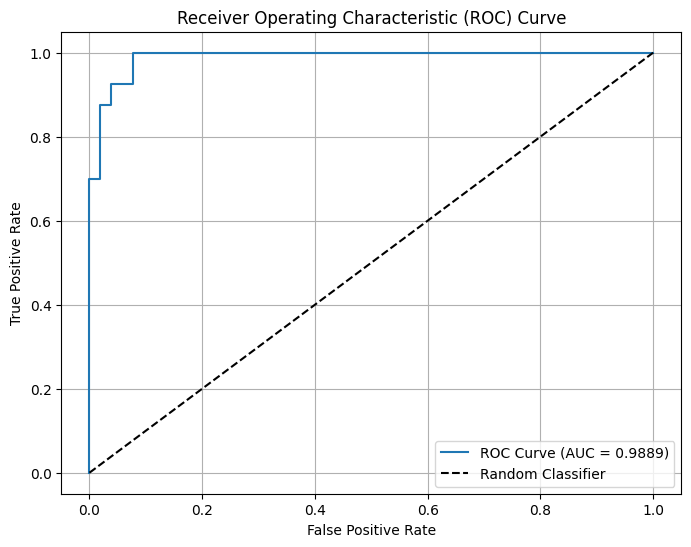

In [37]:
# Load Best Model for Evaluation
best_model = models.mobilenet_v3_small(weights=None)
num_features = best_model.classifier[3].in_features
best_model.classifier[3] = nn.Linear(num_features, 1)
best_model.load_state_dict(torch.load(os.path.join(MODEL_SAVE_DIR, 'best_model.pth')))
best_model = best_model.to(device)
best_model.eval()

# Gather final predictions
all_preds = []
all_labels = []
all_probs = []

print("Evaluating best model on Validation Set...")
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        outputs = best_model(inputs)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Final Metrics
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
roc_auc = roc_auc_score(all_labels, all_probs)

print(f"\n--- Final Metrics ---")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()


In [38]:
from google.colab import files
files.download("models/best_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>